# Fase 3 CRISP-DM — Data Preparation
**Proyecto:** Customer Behavior Analysis — Olist Brazilian E-Commerce  
**Objetivo:** Construir la tabla maestra (`olist_master.csv`) con variables limpias y features de negocio listos para modelado.

El EDA (notebook 01) reveló los problemas de calidad que abordamos aquí:
- Nulos en fechas de entrega → filtrar solo pedidos `delivered` con fechas completas
- 88% de `review_comment_title` vacío → descartamos texto libre, usamos solo score
- 261K duplicados en `geolocation` → no la usamos en la tabla maestra
- Categorías en portugués → traducir al inglés vía `category_translation`

---

## 0. Imports y configuración

In [1]:
import sqlite3
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

ROOT   = Path().resolve().parent
DB_PATH = ROOT / "data" / "olist.db"
OUT_CSV = ROOT / "data" / "olist_master.csv"

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 30)

print(f"DB:     {DB_PATH}  →  existe: {DB_PATH.exists()}")
print(f"Output: {OUT_CSV}")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "D:\ANACONDA\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "D:\ANACONDA\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "D:\ANACONDA\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "D:\ANACONDA\Lib\site-packages\tornado\platform\asyncio.py", line 205, in star

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "D:\ANACONDA\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "D:\ANACONDA\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "D:\ANACONDA\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "D:\ANACONDA\Lib\site-packages\tornado\platform\asyncio.py", line 205, in star

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "D:\ANACONDA\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "D:\ANACONDA\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "D:\ANACONDA\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "D:\ANACONDA\Lib\site-packages\tornado\platform\asyncio.py", line 205, in star

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "D:\ANACONDA\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "D:\ANACONDA\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "D:\ANACONDA\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "D:\ANACONDA\Lib\site-packages\tornado\platform\asyncio.py", line 205, in star

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



DB:     C:\Users\pardo\Documents\portfolio\proyecto 1\data\olist.db  →  existe: True
Output: C:\Users\pardo\Documents\portfolio\proyecto 1\data\olist_master.csv


---
## 1. Carga de tablas desde SQLite
Cargamos solo las tablas necesarias para la tabla maestra. `geolocation` se omite porque sus duplicados la hacen poco útil sin deduplicación previa, y no es necesaria para el modelado de satisfacción.

In [2]:
conn = sqlite3.connect(DB_PATH)

orders       = pd.read_sql("SELECT * FROM orders",               conn)
order_items  = pd.read_sql("SELECT * FROM order_items",          conn)
reviews      = pd.read_sql("SELECT * FROM order_reviews",        conn)
customers    = pd.read_sql("SELECT * FROM customers",            conn)
products     = pd.read_sql("SELECT * FROM products",             conn)
translation  = pd.read_sql("SELECT * FROM category_translation", conn)

conn.close()

print(f"orders:      {orders.shape}")
print(f"order_items: {order_items.shape}")
print(f"reviews:     {reviews.shape}")
print(f"customers:   {customers.shape}")
print(f"products:    {products.shape}")
print(f"translation: {translation.shape}")

orders:      (99441, 8)
order_items: (112650, 7)
reviews:     (99224, 7)
customers:   (99441, 5)
products:    (32951, 9)
translation: (71, 2)


---
## 2. Limpieza de datos

### 2.1 Filtro de pedidos: solo `delivered` con fechas completas
**Decisión de negocio:** Solo los pedidos entregados tienen fecha de entrega real, que es la variable clave para calcular el retraso (`delivery_delay_days`) y correlacionarlo con la satisfacción del cliente.  
Los pedidos en otros estados (cancelados, en tránsito) no son comparables y podrían sesgar el modelo.

In [3]:
n_total = len(orders)

# Paso 1: filtrar por status
orders_del = orders[orders["order_status"] == "delivered"].copy()
print(f"Delivered:          {len(orders_del):>7,}  ({len(orders_del)/n_total*100:.1f}% del total)")

# Paso 2: parsear todas las columnas de fecha
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in date_cols:
    orders_del[col] = pd.to_datetime(orders_del[col], errors="coerce")

# Paso 3: eliminar filas donde falten las fechas imprescindibles
# order_delivered_customer_date → fecha real (para calcular delay)
# order_estimated_delivery_date → fecha prometida (para comparar)
# order_purchase_timestamp → origen del pedido (para delivery_days)
critical_dates = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
orders_del.dropna(subset=critical_dates, inplace=True)
print(f"Con fechas críticas:{len(orders_del):>7,}  ({len(orders_del)/n_total*100:.1f}% del total)")

Delivered:           96,478  (97.0% del total)


Con fechas críticas: 96,470  (97.0% del total)


### 2.2 Parseo de fechas en `order_items`
`shipping_limit_date` puede tener valores nulos o malformados. Lo parseamos para coherencia del schema, aunque no lo usamos como feature en esta fase.

In [4]:
order_items["shipping_limit_date"] = pd.to_datetime(
    order_items["shipping_limit_date"], errors="coerce"
)
print(f"order_items dtypes:\n{order_items.dtypes}")

order_items dtypes:
order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object


### 2.3 Deduplicación de reseñas
El EDA mostró que `order_reviews` puede tener múltiples reseñas para el mismo `order_id` (por reintentos del sistema). Para el join 1-a-1 con pedidos, conservamos la reseña más reciente según `review_answer_timestamp`.

In [5]:
reviews["review_answer_timestamp"] = pd.to_datetime(
    reviews["review_answer_timestamp"], errors="coerce"
)

n_reviews_raw = len(reviews)
reviews_dedup = (
    reviews
    .sort_values("review_answer_timestamp", ascending=False)
    .drop_duplicates(subset="order_id", keep="first")  # más reciente primero
    [["order_id", "review_score"]]                     # solo columnas necesarias
)

print(f"Reseñas totales:       {n_reviews_raw:,}")
print(f"Reseñas deduplicadas:  {len(reviews_dedup):,}")
print(f"Eliminadas:            {n_reviews_raw - len(reviews_dedup):,}")

Reseñas totales:       99,224
Reseñas deduplicadas:  98,673
Eliminadas:            551


### 2.4 Traducción de categorías al inglés
Unimos `products` con `category_translation`. Los productos sin categoría asignada (610 casos detectados en EDA) reciben el valor `'unknown'` para no perder esos pedidos en los joins posteriores.

In [6]:
# Renombramos la columna de traducción para claridad
translation = translation.rename(
    columns={"product_category_name_english": "category_en"}
)

products_cat = products[["product_id", "product_category_name", "product_weight_g"]].merge(
    translation, on="product_category_name", how="left"
)

# Rellenar categorías sin traducción con 'unknown'
products_cat["category_en"] = products_cat["category_en"].fillna("unknown")

print(f"Productos sin categoría traducida: {products_cat['category_en'].eq('unknown').sum()}")
print(f"Categorías únicas en inglés:       {products_cat['category_en'].nunique()}")

Productos sin categoría traducida: 623
Categorías únicas en inglés:       72


---
## 3. Merge de tablas
Construimos la tabla maestra en dos pasos:  
1. Agregar `order_items` al nivel `order_id` (de múltiples filas a una por pedido)  
2. Hacer los joins sucesivos alrededor de `orders`

### 3.1 Agregación de order_items al nivel de pedido
Cada pedido puede tener varios ítems (distintos productos). Necesitamos una fila por pedido, por eso agregamos con sumas y conteos.

In [7]:
items_agg = order_items.groupby("order_id", as_index=False).agg(
    n_items        =("order_item_id",  "count"),   # cantidad de ítems en el pedido
    price_total    =("price",          "sum"),      # valor total de productos
    freight_total  =("freight_value",  "sum"),      # coste logístico total
    product_id     =("product_id",     "first"),    # producto principal (primer ítem)
    seller_id      =("seller_id",      "first"),    # vendedor principal
)

print(f"items_agg shape: {items_agg.shape}")
print(items_agg.dtypes)

items_agg shape: (98666, 6)
order_id          object
n_items            int64
price_total      float64
freight_total    float64
product_id        object
seller_id         object
dtype: object


### 3.2 Join central
El join sigue la lógica del SQL en `sql/02_data_preparation.sql`:  
- `INNER JOIN` con ítems y clientes (deben existir siempre)  
- `LEFT JOIN` con reseñas (no todos los pedidos tienen reseña)  
- `LEFT JOIN` con categoría de producto (puede ser unknown)

In [8]:
# Base: pedidos delivered con fechas
master = orders_del.copy()

# + ítems agregados (inner: todo pedido debe tener al menos un ítem)
master = master.merge(items_agg, on="order_id", how="inner")

# + categoría del producto principal (left: unknown si no hay)
master = master.merge(
    products_cat[["product_id", "category_en", "product_weight_g"]],
    on="product_id", how="left"
)

# + reseña deduplicada (left: no todos los pedidos tienen reseña)
master = master.merge(reviews_dedup, on="order_id", how="left")

# + datos del cliente (inner: todo pedido debe tener cliente)
customers_slim = customers[["customer_id", "customer_unique_id",
                             "customer_city", "customer_state"]]
master = master.merge(customers_slim, on="customer_id", how="inner")

print(f"Tabla maestra antes de feature engineering: {master.shape}")
print(f"\nNulos por columna:")
print(master.isnull().sum()[master.isnull().sum() > 0])

Tabla maestra antes de feature engineering: (96470, 19)

Nulos por columna:


order_approved_at                14
order_delivered_carrier_date      1
product_weight_g                 16
review_score                    646
dtype: int64


---
## 4. Feature Engineering
Construimos las variables derivadas que el modelo necesitará.

### 4.1 `delivery_delay_days` — Retraso de entrega
**Fórmula:** `fecha_entrega_real − fecha_entrega_estimada` (en días)  
- **Valor positivo:** el pedido llegó tarde → experiencia negativa  
- **Valor negativo:** el pedido llegó antes de lo prometido → experiencia positiva  
- **Valor cero:** puntual

Esta variable es el predictor candidato más fuerte de `review_score` según la correlación del EDA.

In [9]:
master["delivery_days"] = (
    master["order_delivered_customer_date"] - master["order_purchase_timestamp"]
).dt.days

master["delivery_delay_days"] = (
    master["order_delivered_customer_date"] - master["order_estimated_delivery_date"]
).dt.days

# Eliminamos registros con delivery_days <= 0: datos corruptos donde
# la entrega figura antes o igual que la compra (imposible en producción)
n_before = len(master)
master = master[master["delivery_days"] > 0].copy()
print(f"Registros eliminados (delivery_days <= 0): {n_before - len(master)}")

print(f"\ndelivery_delay_days — estadísticas:")
print(master["delivery_delay_days"].describe().round(1))

Registros eliminados (delivery_days <= 0): 13

delivery_delay_days — estadísticas:
count    96457.0
mean       -11.9
std         10.2
min       -147.0
25%        -17.0
50%        -12.0
75%         -7.0
max        188.0
Name: delivery_delay_days, dtype: float64


### 4.2 `is_negative_review` — Flag de reseña negativa
**Decisión:** Scores 1 y 2 representan insatisfacción clara (umbral habitual en e-commerce).  
Score 3 es neutral y no se incluye como negativo. Los pedidos sin reseña reciben `NaN` (no imputamos: ausencia de reseña ≠ satisfacción).

In [10]:
master["is_negative_review"] = (master["review_score"] <= 2).astype("Int8")
# Int8 nullable: permite NaN donde no hay reseña
master.loc[master["review_score"].isna(), "is_negative_review"] = pd.NA

# Distribución
neg = master["is_negative_review"].value_counts(dropna=False)
print("is_negative_review:")
print(f"  Negativas (1): {neg.get(1, 0):,}  ({neg.get(1, 0)/len(master)*100:.1f}%)")
print(f"  Positivas (0): {neg.get(0, 0):,}  ({neg.get(0, 0)/len(master)*100:.1f}%)")
print(f"  Sin reseña:    {master['is_negative_review'].isna().sum():,}  ({master['is_negative_review'].isna().sum()/len(master)*100:.1f}%)")

is_negative_review:
  Negativas (1): 12,271  (12.7%)
  Positivas (0): 83,540  (86.6%)
  Sin reseña:    646  (0.7%)


### 4.3 `order_month` — Mes de compra
Captura la estacionalidad: el EDA mostró que Nov 2017 tuvo un pico (Black Friday Brasil). Esta variable permite al modelo aprender patrones temporales.

In [11]:
master["order_month"]   = master["order_purchase_timestamp"].dt.to_period("M").astype(str)
master["order_weekday"] = master["order_purchase_timestamp"].dt.dayofweek  # 0=Lunes, 6=Domingo
master["order_hour"]    = master["order_purchase_timestamp"].dt.hour

print("order_month — primeros valores únicos:")
print(sorted(master["order_month"].unique())[:8])

order_month — primeros valores únicos:
['2016-09', '2016-10', '2016-12', '2017-01', '2017-02', '2017-03', '2017-04', '2017-05']


### 4.4 `freight_ratio` — Ratio flete / precio del producto
Indica qué proporción del gasto fue logística. Un ratio alto puede indicar productos baratos con envío costoso (impacto en percepción de valor).

In [12]:
master["freight_ratio"] = (master["freight_total"] / master["price_total"].replace(0, np.nan)).round(4)

print("freight_ratio — estadísticas:")
print(master["freight_ratio"].describe().round(3))

freight_ratio — estadísticas:
count    96457.000
mean         0.308
std          0.312
min          0.000
25%          0.132
50%          0.224
75%          0.381
max         21.447
Name: freight_ratio, dtype: float64


---
## 5. Validación de la tabla maestra
Revisamos la calidad final: tipos de datos correctos, nulos residuales esperados, rangos válidos.

In [13]:
# Selección y orden de columnas para la tabla final
final_cols = [
    "order_id",
    "customer_unique_id",
    "customer_state",
    "customer_city",
    "order_purchase_timestamp",
    "order_month",
    "order_weekday",
    "order_hour",
    "category_en",
    "n_items",
    "price_total",
    "freight_total",
    "freight_ratio",
    "product_weight_g",
    "delivery_days",
    "delivery_delay_days",
    "review_score",
    "is_negative_review",
]

master_final = master[final_cols].copy()

print(f"Shape final: {master_final.shape}")
print(f"\nDtypes:")
print(master_final.dtypes)
print(f"\nNulos residuales:")
nulls = master_final.isnull().sum()
print(nulls[nulls > 0])

Shape final: (96457, 18)

Dtypes:
order_id                            object
customer_unique_id                  object
customer_state                      object
customer_city                       object
order_purchase_timestamp    datetime64[ns]
order_month                         object
order_weekday                        int32
order_hour                           int32
category_en                         object
n_items                              int64
price_total                        float64
freight_total                      float64
freight_ratio                      float64
product_weight_g                   float64
delivery_days                        int64
delivery_delay_days                  int64
review_score                       float64
is_negative_review                    Int8
dtype: object

Nulos residuales:


product_weight_g       16
review_score          646
is_negative_review    646
dtype: int64


In [14]:
# Checks de integridad
assert master_final["order_id"].nunique() == len(master_final), "order_id no es único!"
assert (master_final["delivery_days"] > 0).all(), "Hay delivery_days <= 0"
assert master_final["review_score"].dropna().between(1, 5).all(), "review_score fuera de rango"
assert master_final["price_total"].ge(0).all(), "Hay price_total negativo"

print("Todos los checks de integridad pasaron.")
print(f"\nResumen estadístico de features clave:")
display(master_final[["delivery_days", "delivery_delay_days",
                       "price_total", "freight_ratio",
                       "review_score", "n_items"]].describe().round(2))

Todos los checks de integridad pasaron.

Resumen estadístico de features clave:


,delivery_days,delivery_delay_days,price_total,freight_ratio,review_score,n_items
count,96457.00,96457.00,96457.00,96457.00,95811.00,96457.00
mean,12.10,-11.88,137.04,0.31,4.16,1.14
std,9.55,10.18,209.06,0.31,1.28,0.54
min,1.00,-147.00,0.85,0.00,1.00,1.00
25%,6.00,-17.00,45.90,0.13,4.00,1.00
50%,10.00,-12.00,86.50,0.22,5.00,1.00
75%,15.00,-7.00,149.90,0.38,5.00,1.00
max,209.00,188.00,13440.00,21.45,5.00,21.00


---
## 6. Visualizaciones de validación
Confirmamos visualmente que los features calculados tienen las distribuciones esperadas.

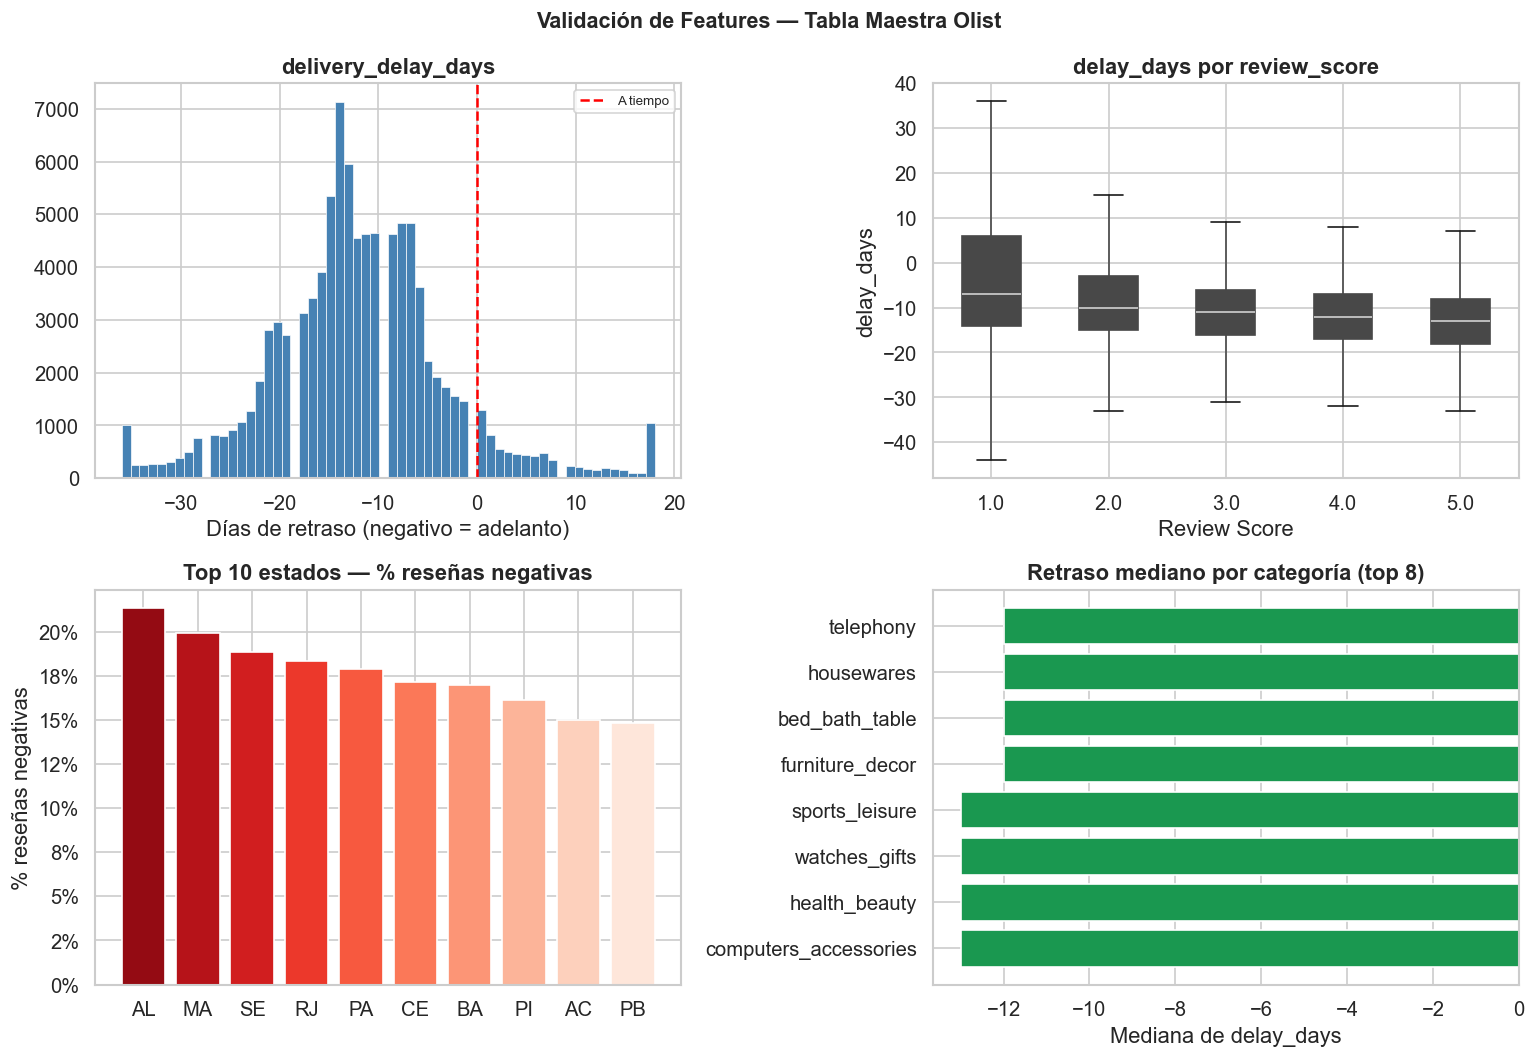

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# -- delivery_delay_days --
ax = axes[0, 0]
p1, p99 = master_final["delivery_delay_days"].quantile([0.01, 0.99])
clipped = master_final["delivery_delay_days"].clip(p1, p99)
ax.hist(clipped, bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
ax.axvline(0, color="red", linewidth=1.5, linestyle="--", label="A tiempo")
ax.set_title("delivery_delay_days", fontweight="bold")
ax.set_xlabel("Días de retraso (negativo = adelanto)")
ax.legend(fontsize=8)

# -- review_score vs delivery_delay_days (boxplot) --
ax = axes[0, 1]
reviews_with_score = master_final.dropna(subset=["review_score", "delivery_delay_days"])
reviews_with_score.boxplot(
    column="delivery_delay_days",
    by="review_score",
    ax=ax,
    patch_artist=True,
    showfliers=False,
)
ax.set_title("delay_days por review_score", fontweight="bold")
ax.set_xlabel("Review Score")
ax.set_ylabel("delay_days")
plt.sca(ax)
plt.title("delay_days por review_score", fontweight="bold")

# -- is_negative_review por estado --
ax = axes[1, 0]
neg_by_state = (
    master_final.dropna(subset=["is_negative_review"])
    .groupby("customer_state")["is_negative_review"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
ax.bar(neg_by_state.index, neg_by_state.values * 100,
       color=sns.color_palette("Reds_r", 10), edgecolor="white")
ax.set_title("Top 10 estados — % reseñas negativas", fontweight="bold")
ax.set_ylabel("% reseñas negativas")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# -- delivery_days por categoría (top 8) --
ax = axes[1, 1]
top_cats = master_final["category_en"].value_counts().head(8).index
cat_delay = (
    master_final[master_final["category_en"].isin(top_cats)]
    .groupby("category_en")["delivery_delay_days"]
    .median()
    .sort_values()
)
colors_cat = ["#d73027" if v > 0 else "#1a9850" for v in cat_delay.values]
ax.barh(cat_delay.index, cat_delay.values, color=colors_cat, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Retraso mediano por categoría (top 8)", fontweight="bold")
ax.set_xlabel("Mediana de delay_days")

plt.suptitle("Validación de Features — Tabla Maestra Olist", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "dashboard" / "feature_validation.png", bbox_inches="tight")
plt.show()

---
## 7. Exportar tabla maestra a CSV
`data/olist_master.csv` es el punto de entrada para los notebooks de Fase 4 (Modelado).  
Exportamos con `index=False` para evitar columnas índice innecesarias al recargar.

In [16]:
master_final.to_csv(OUT_CSV, index=False)

size_mb = OUT_CSV.stat().st_size / 1024 / 1024
print(f"Exportado: {OUT_CSV}")
print(f"Tamaño:    {size_mb:.2f} MB")
print(f"Filas:     {len(master_final):,}")
print(f"Columnas:  {len(master_final.columns)}")
print(f"\nColumnas: {list(master_final.columns)}")

Exportado: C:\Users\pardo\Documents\portfolio\proyecto 1\data\olist_master.csv
Tamaño:    15.36 MB
Filas:     96,457
Columnas:  18

Columnas: ['order_id', 'customer_unique_id', 'customer_state', 'customer_city', 'order_purchase_timestamp', 'order_month', 'order_weekday', 'order_hour', 'category_en', 'n_items', 'price_total', 'freight_total', 'freight_ratio', 'product_weight_g', 'delivery_days', 'delivery_delay_days', 'review_score', 'is_negative_review']


---
## 8. Resumen de decisiones — Data Preparation

| Decisión | Motivo |
|----------|--------|
| Filtrar solo `delivered` | Solo pedidos completos tienen fecha de entrega real para calcular delay |
| Eliminar `delivery_days <= 0` | Datos corruptos: entrega antes de la compra es imposible |
| LEFT JOIN con reseñas | No todos los pedidos tienen reseña; imputar sesgaría el modelo |
| `is_negative_review` con umbral ≤ 2 | Scores 1–2 = insatisfacción clara; score 3 es neutral en e-commerce |
| `category_en = 'unknown'` para nulos | Preservar pedidos sin categoría evita pérdida de datos de negocio |
| No usar `geolocation` | 261K duplicados y no es necesaria para el modelado de satisfacción |
| `product_id = first()` en agregación | Pedidos multi-producto: usamos el producto dominante como proxy de categoría |

### Variables en la tabla maestra

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `order_id` | ID | Clave primaria |
| `customer_unique_id` | ID | Cliente real (estable entre pedidos) |
| `customer_state` | Categórico | Estado del cliente (Brasil) |
| `order_month` | Periodo | Mes de compra (YYYY-MM) |
| `order_weekday` | Entero | Día de la semana (0=Lunes) |
| `order_hour` | Entero | Hora de compra |
| `category_en` | Categórico | Categoría del producto en inglés |
| `n_items` | Entero | Número de ítems en el pedido |
| `price_total` | Float | Valor total de productos (BRL) |
| `freight_total` | Float | Coste logístico total (BRL) |
| `freight_ratio` | Float | freight / price (ratio de logística) |
| `product_weight_g` | Float | Peso del producto principal (g) |
| `delivery_days` | Entero | Días desde compra hasta entrega |
| `delivery_delay_days` | Entero | Retraso vs. fecha estimada (+ = tarde) |
| `review_score` | Entero | Score 1–5 (NaN si no hay reseña) |
| `is_negative_review` | Binario | 1 si score ≤ 2, 0 si score ≥ 3, NaN si no hay |

### Próximos pasos — Fase 4 (Modeling)
- Segmentación RFM de clientes (KMeans sobre Recency, Frequency, Monetary)
- Predicción de `is_negative_review` (Logistic Regression / Random Forest)
- Análisis de importancia de features